# Reproduce Results Without Re-running Inference

This notebook reconstructs the control and ablation comparisons using existing metrics CSV files.
Inference is not re-run here to save time. Inference takes roughly 2 hours per run per model.

Also, while meteor was used in computations during testing it was found to be highly correlated to CIDEr (R2 ~0.75) making it a redundant metric.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Control result CSVs (relative paths from the repository root)
control_files = {
    'Gemma 4B': './results/metrics-results/control-set/gemma-4b_BaseSet_20260426_140144.csv',
    'Molmo 2 4B': './results/metrics-results/control-set/molmo2_BaseSet_20260426_140459.csv'
}

def print_summary_stats(df, model_name):
    score_cols = [c for c in df.columns if c.endswith('_Score')]
    stats = df[score_cols].agg(['mean', 'median', 'min', 'max']).round(4)
    print(f'--- Summary Statistics for {model_name} ---')
    display(stats)
    print('')

control_dfs = []
for model_name, path in control_files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['Model'] = model_name
        control_dfs.append(df)
        print_summary_stats(df, model_name)
    else:
        print(f'Warning: Control file missing: {path}')

if control_dfs:
    df_control = pd.concat(control_dfs, ignore_index=True)
else:
    raise FileNotFoundError('No control CSV files were found. Please check the relative paths.')

--- Summary Statistics for Gemma 4B ---


,CIDEr_Score,SPICE_Score,METEOR_Score,CLIPScore_Score
mean,0.4242,0.1616,0.3731,0.3175
median,0.3254,0.1481,0.3647,0.3169
min,0.0000,0.0000,0.0000,0.1742
max,3.7324,0.7143,0.9896,0.4294



--- Summary Statistics for Molmo 2 4B ---


,CIDEr_Score,SPICE_Score,METEOR_Score,CLIPScore_Score
mean,0.4512,0.2031,0.3820,0.3221
median,0.3484,0.1935,0.3713,0.3220
min,0.0000,0.0000,0.0307,0.1733
max,4.1926,0.6667,0.9836,0.4407


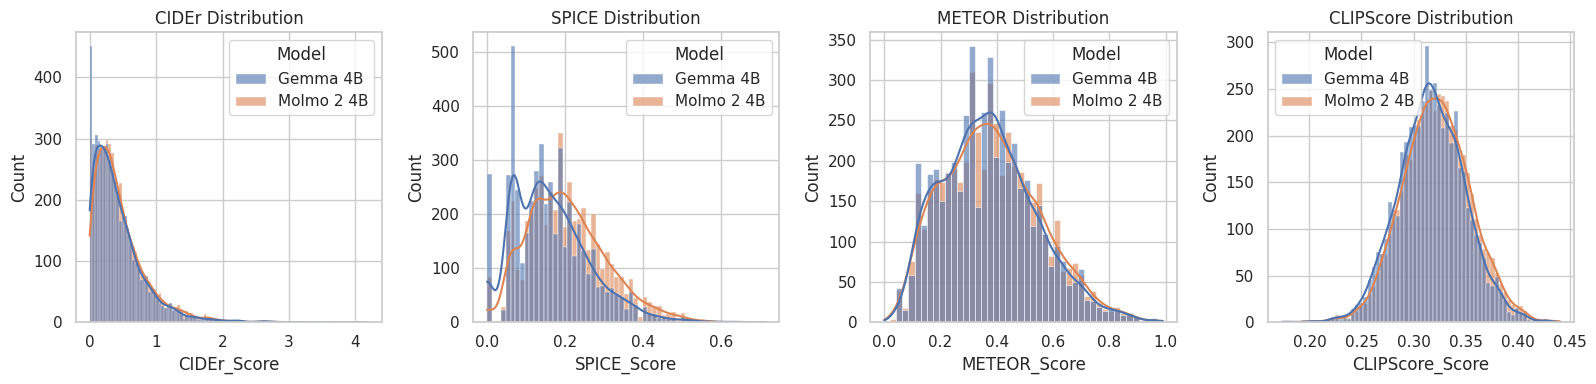

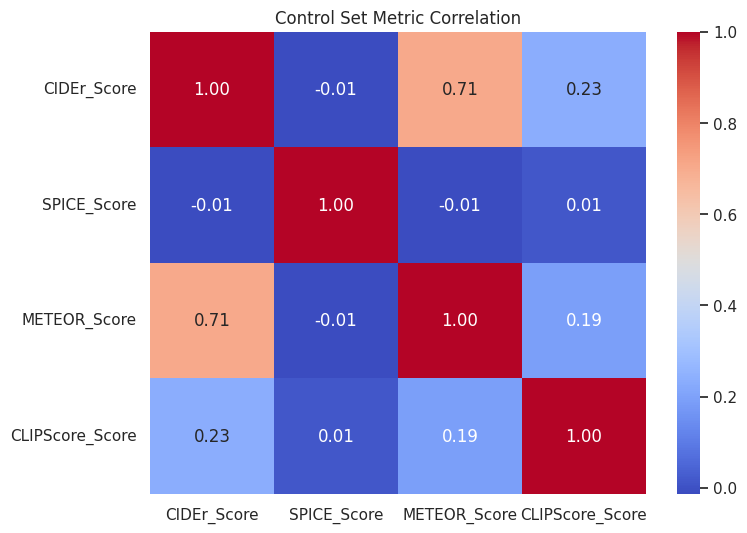

In [3]:
score_cols = [c for c in df_control.columns if c.endswith('_Score')]
n_metrics = len(score_cols)

fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), squeeze=False)
axes = axes[0]
for i, col in enumerate(score_cols):
    sns.histplot(data=df_control, x=col, hue='Model', kde=True, ax=axes[i], alpha=0.6, edgecolor=None)
    axes[i].set_title(col.replace('_Score', '') + ' Distribution')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df_control[score_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Control Set Metric Correlation')
plt.show()

In [4]:
# Ablation files for both noise and blur comparisons
ablation_files = {
    ('Gemma 4B', 'Noise'): {
        80: './results/metrics-results/ablation-set/gemma-4b_noise80_20260426_184251.csv',
        160: './results/metrics-results/ablation-set/gemma-4b_noise160_20260427_185200.csv',
        240: './results/metrics-results/ablation-set/gemma-4b_noise240_20260501_191532.csv'
    },
    ('Gemma 4B', 'Blur'): {
        31: './results/metrics-results/ablation-set/gemma4b_blur31_20260426_140844.csv',
        61: './results/metrics-results/ablation-set/gemma-4b_blur61_20260427_185501.csv',
        91: './results/metrics-results/ablation-set/gemma-4b_blur91_20260501_191149.csv'
    },
    ('Molmo 2 4B', 'Noise'): {
        80: './results/metrics-results/ablation-set/molmo2_noise80_20260426_184616.csv',
        160: './results/metrics-results/ablation-set/Molmo2_noise160_20260427_190114.csv',
        240: './results/metrics-results/ablation-set/molmo2_noise_240_20260501_192240.csv'
    },
    ('Molmo 2 4B', 'Blur'): {
        31: './results/metrics-results/ablation-set/molmo2_blur31_20260426_141303.csv',
        61: './results/metrics-results/ablation-set/Molmo2_blur61_20260427_185819.csv',
        91: './results/metrics-results/ablation-set/molmo2_blur91_20260501_191931.csv'
    }
}

ablation_dfs = []
for (model_name, ablation_type), file_map in ablation_files.items():
    for value, path in file_map.items():
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['Model'] = model_name
            df['Ablation_Type'] = ablation_type
            df['Ablation_Value'] = value
            ablation_dfs.append(df)
            print(f'Loaded: {model_name} | {ablation_type} {value} ({len(df)} rows)')
        else:
            print(f'Warning: Missing ablation file for {model_name} | {ablation_type} {value}: {path}')

if ablation_dfs:
    df_ablation = pd.concat(ablation_dfs, ignore_index=True)
    print('Combined ablation preview:')
    display(df_ablation.head())
else:
    raise FileNotFoundError('No ablation CSV files were loaded. Please check the relative paths.')

Loaded: Gemma 4B | Noise 80 (5000 rows)
Loaded: Gemma 4B | Noise 160 (5000 rows)
Loaded: Gemma 4B | Noise 240 (5000 rows)
Loaded: Gemma 4B | Blur 31 (5000 rows)
Loaded: Gemma 4B | Blur 61 (5000 rows)
Loaded: Gemma 4B | Blur 91 (5000 rows)
Loaded: Molmo 2 4B | Noise 80 (5000 rows)
Loaded: Molmo 2 4B | Noise 160 (5000 rows)
Loaded: Molmo 2 4B | Noise 240 (5000 rows)
Loaded: Molmo 2 4B | Blur 31 (5000 rows)
Loaded: Molmo 2 4B | Blur 61 (5000 rows)
Loaded: Molmo 2 4B | Blur 91 (5000 rows)
Combined ablation preview:


,Image_ID,Generated_Caption,CIDEr_Score,SPICE_Score,METEOR_Score,CLIPScore_Score,Model,Ablation_Type,Ablation_Value
0,000000456865.jpg,An airplane is visible on an airfield under a ...,0.3840,0.0000,0.3803,0.2573,Gemma 4B,Noise,80
1,000000435003.jpg,A cluttered desk setup with multiple monitors ...,0.7387,0.1333,0.5617,0.2925,Gemma 4B,Noise,80
2,000000084431.jpg,"A television screen is visible above a large, ...",0.0017,0.2222,0.1181,0.2607,Gemma 4B,Noise,80
3,000000402346.jpg,A red and white flower is above a bowl of red ...,0.4936,0.2609,0.4180,0.3608,Gemma 4B,Noise,80
4,000000294695.jpg,People gather on a beach with American flags d...,0.4943,0.0690,0.4543,0.3262,Gemma 4B,Noise,80


Ablation summary statistics (Including Control=0):


,Model,Ablation_Type,Ablation_Value,CIDEr_Score_mean,CIDEr_Score_median,CIDEr_Score_var,CIDEr_Score_skew,SPICE_Score_mean,SPICE_Score_median,SPICE_Score_var,SPICE_Score_skew,CLIPScore_Score_mean,CLIPScore_Score_median,CLIPScore_Score_var,CLIPScore_Score_skew
0,Gemma 4B,Blur,0,0.424196,0.32535,0.157292,2.108102,0.161644,0.1481,0.009718,0.818940,0.317537,0.31690,0.001018,0.007632
1,Gemma 4B,Blur,31,0.271789,0.16170,0.112100,2.362863,0.108551,0.0870,0.008447,0.961194,0.284905,0.28740,0.001572,-0.322720
2,Gemma 4B,Blur,61,0.162420,0.05130,0.066375,2.815642,0.072585,0.0606,0.006349,1.232953,0.258601,0.26000,0.002117,-0.147498
3,Gemma 4B,Blur,91,0.085300,0.00320,0.034931,4.249379,0.044702,0.0000,0.004320,1.788354,0.235129,0.23345,0.002121,0.062789
4,Gemma 4B,Noise,0,0.424196,0.32535,0.157292,2.108102,0.161644,0.1481,0.009718,0.818940,0.317537,0.31690,0.001018,0.007632
5,Gemma 4B,Noise,80,0.295554,0.19275,0.114272,2.016767,0.116592,0.1053,0.008543,0.770847,0.286102,0.29080,0.002050,-0.495370
6,Gemma 4B,Noise,160,0.115727,0.01090,0.046305,3.176121,0.054503,0.0000,0.005089,1.506613,0.236447,0.23680,0.002723,-0.112174
7,Gemma 4B,Noise,240,0.031003,0.00120,0.012295,6.697268,0.022203,0.0000,0.001971,2.712416,0.202371,0.20175,0.002097,0.023166
8,Molmo 2 4B,Blur,0,0.451184,0.34835,0.154985,1.971764,0.203130,0.1935,0.010407,0.586515,0.322114,0.32200,0.001059,0.017491
9,Molmo 2 4B,Blur,31,0.395785,0.28835,0.152851,1.967511,0.172823,0.1622,0.011036,0.640980,0.298249,0.30080,0.001643,-0.462384


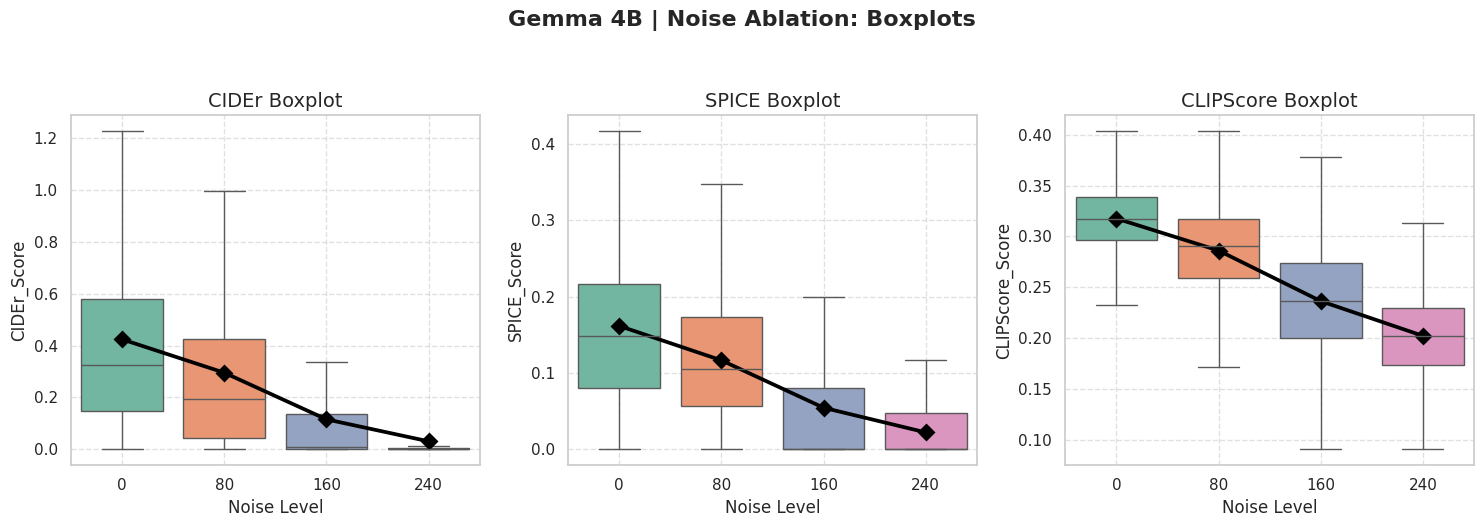

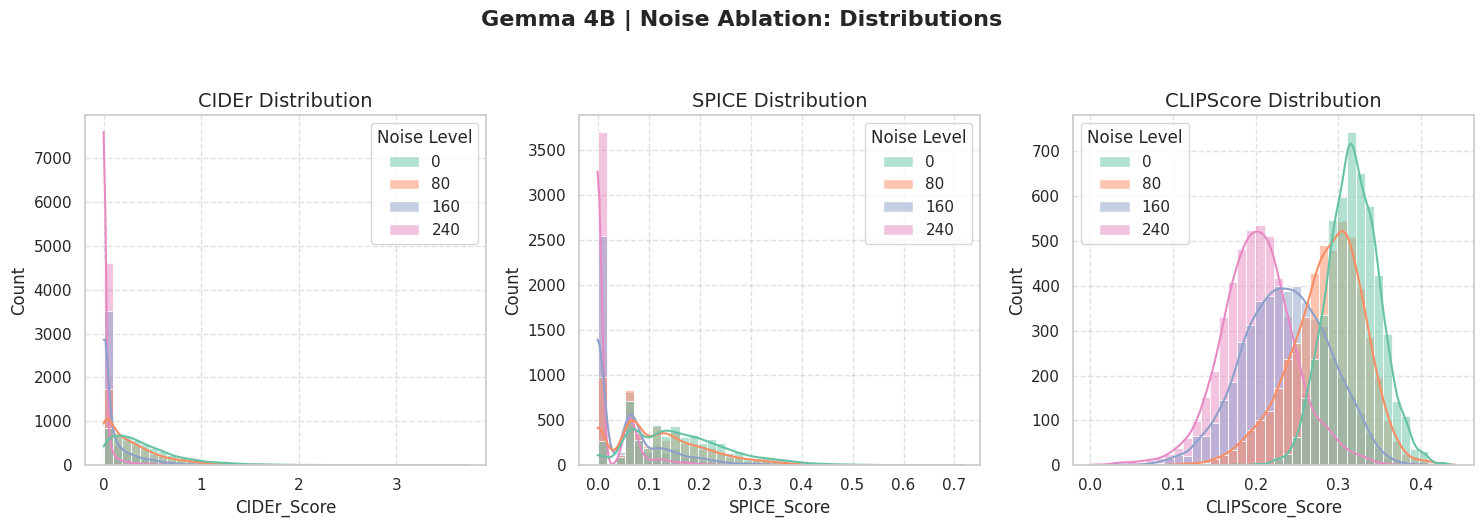

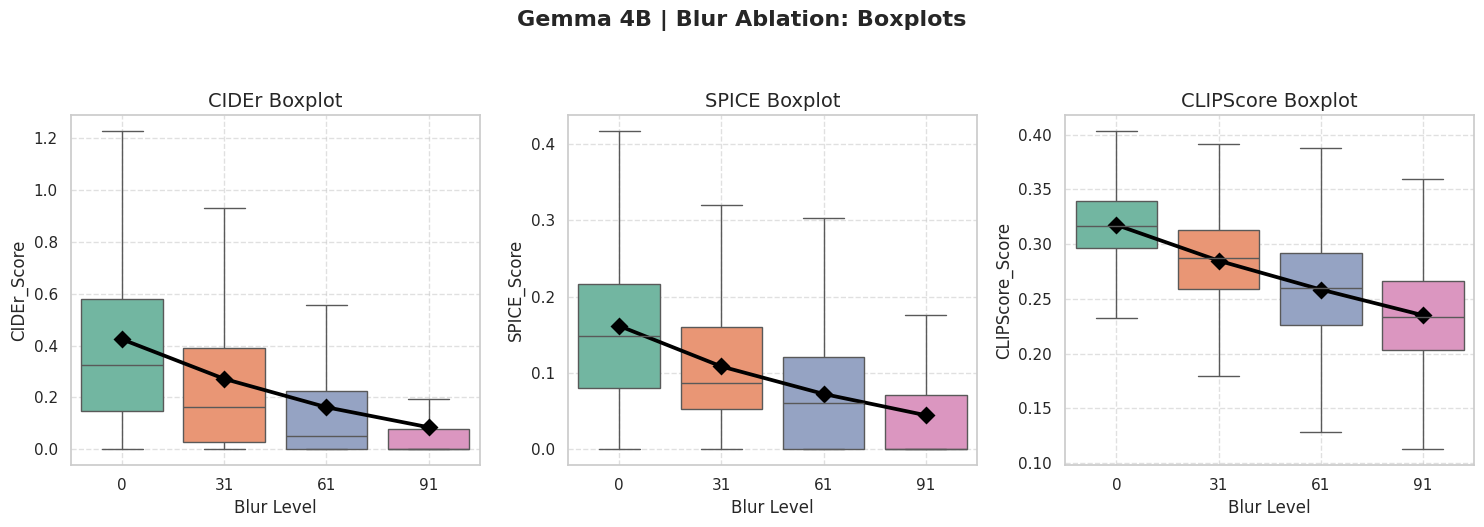

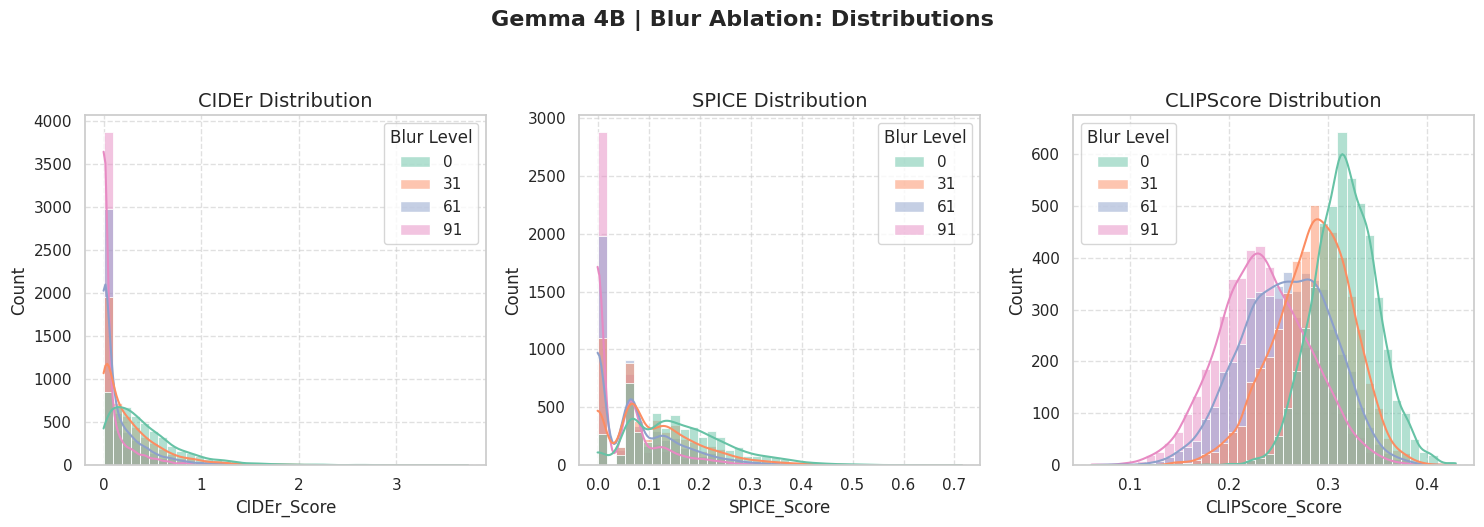

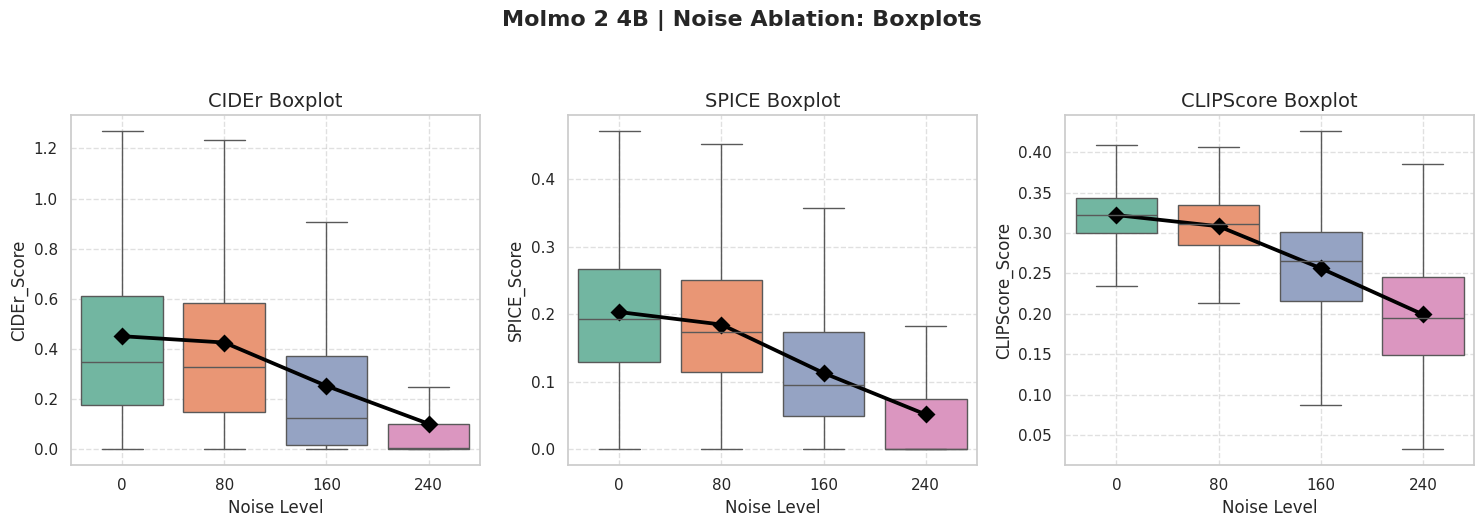

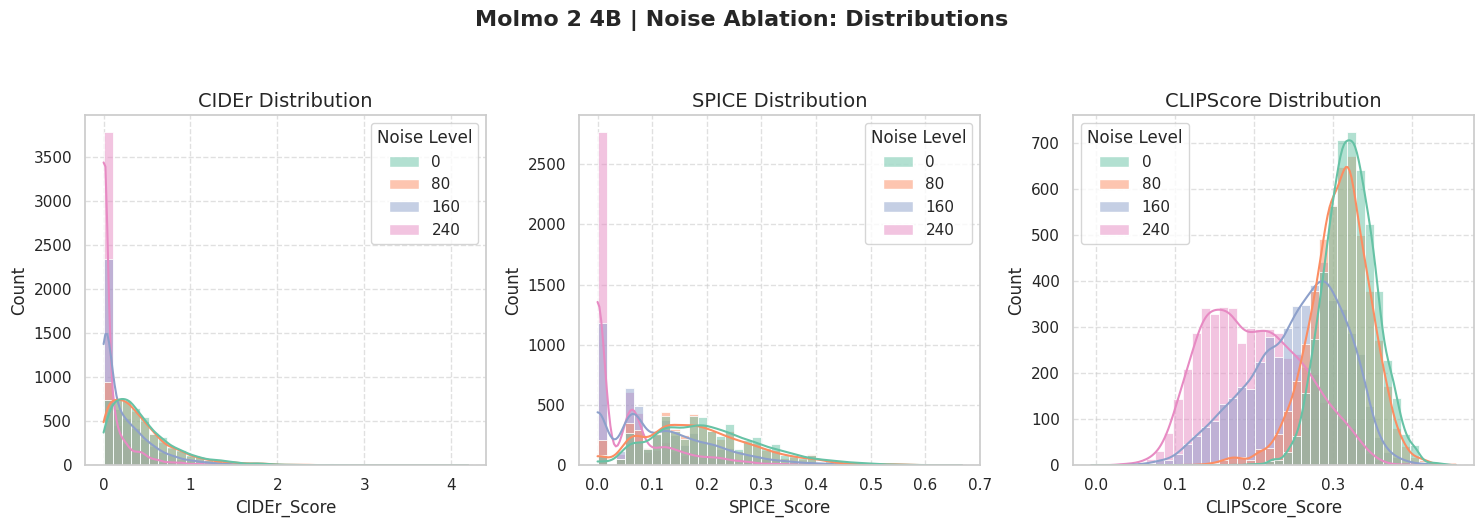

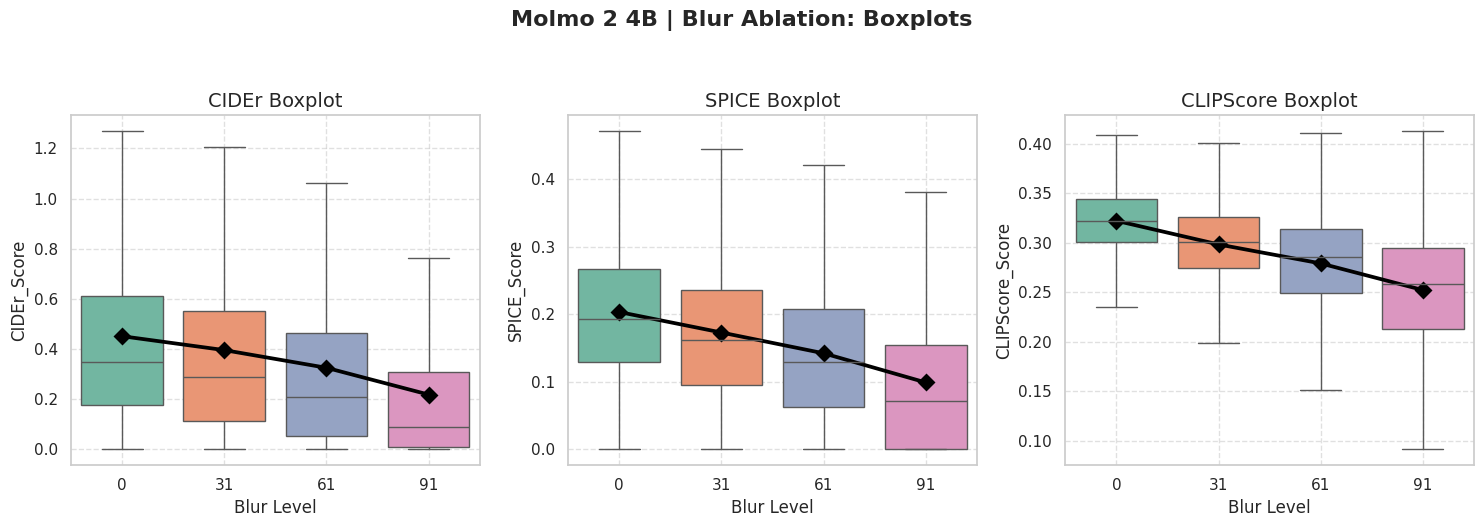

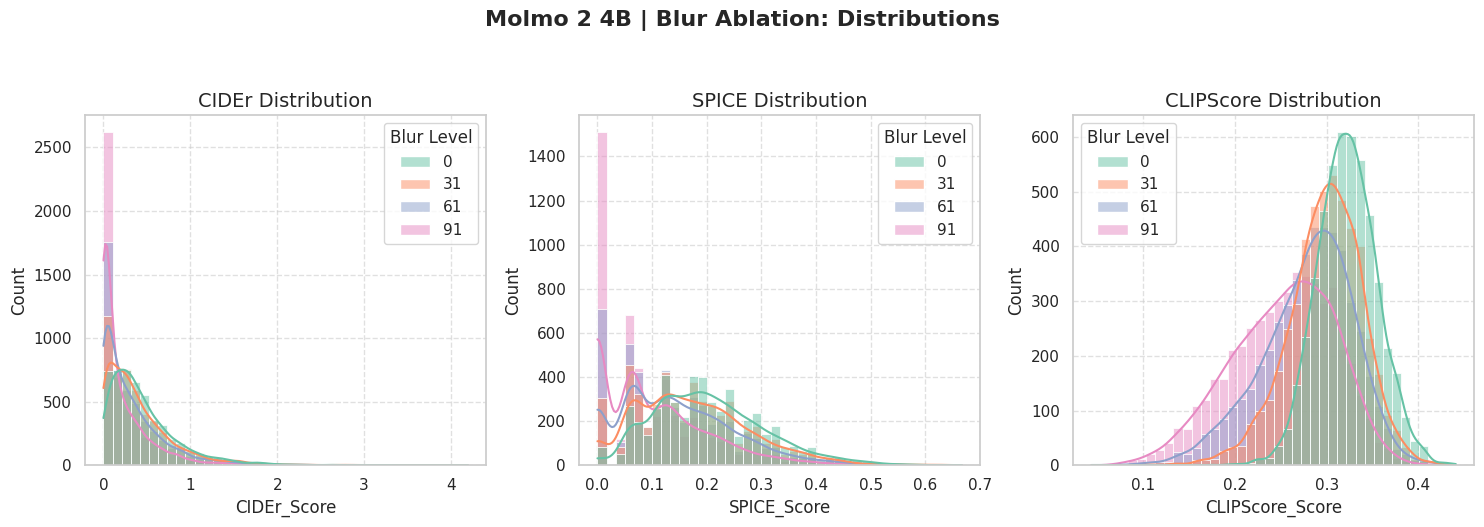

In [5]:


# Identify metric columns
metrics = [c for c in df_ablation.columns if c.endswith('_Score') and 'METEOR' not in c]

# ==========================================
# FIX: Add control data (Level 0) to complete the ablation paths
# ==========================================
control_noise = df_control.copy()
control_noise['Ablation_Type'] = 'Noise'
control_noise['Ablation_Value'] = 0

control_blur = df_control.copy()
control_blur['Ablation_Type'] = 'Blur'
control_blur['Ablation_Value'] = 0

# Combine into a single dataframe so the graphs start at 0
df_all = pd.concat([control_noise, control_blur, df_ablation], ignore_index=True)

# 1. Print summary statistics
summary_stats = df_all.groupby(['Model', 'Ablation_Type', 'Ablation_Value'])[metrics].agg(['mean', 'median', 'var', 'skew'])
summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
summary_stats = summary_stats.reset_index()
print('Ablation summary statistics (Including Control=0):')
display(summary_stats)

# 2. Generate the 8 figures grouped by Model and Ablation Type
models = df_all['Model'].unique()
ablation_types = ['Noise', 'Blur']

for model_name in models:
    for ablation_type in ablation_types:
        # Filter data for this specific model and study
        subset = df_all[(df_all['Model'] == model_name) & (df_all['Ablation_Type'] == ablation_type)].copy()
        
        if subset.empty:
            continue
            
        # Sort by value so the line paths connect properly (e.g., 0 -> 80 -> 160)
        subset = subset.sort_values(by='Ablation_Value')
        subset['Condition'] = subset['Ablation_Value'].astype(str)
        plot_order = subset['Condition'].unique()
        
        # ==========================================
        # GRAPH 1: Boxplots for this Model + Study
        # ==========================================
        fig_box, axes_box = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5), sharey=False)
        if len(metrics) == 1:
            axes_box = [axes_box]

        for i, metric in enumerate(metrics):
            ax = axes_box[i]
            sns.boxplot(
                data=subset,
                x='Condition',
                y=metric,
                hue='Condition', 
                order=plot_order,
                ax=ax,
                palette='Set2',
                showfliers=False,
                legend=False
            )
            # The "path" connecting the means
            sns.pointplot(
                data=subset,
                x='Condition',
                y=metric,
                order=plot_order,
                ax=ax,
                markers='D',
                linestyles='-',
                estimator='mean',
                errorbar=None, 
                color='black',
                legend=False
            )

            metric_clean = metric.replace('_Score', '')
            ax.set_title(f'{metric_clean} Boxplot', fontsize=14)
            ax.set_xlabel(f'{ablation_type} Level', fontsize=12)
            ax.set_ylabel(metric, fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.6)

        plt.suptitle(f'{model_name} | {ablation_type} Ablation: Boxplots', fontsize=16, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()

        # ==========================================
        # GRAPH 2: Distributions for this Model + Study
        # ==========================================
        fig_dist, axes_dist = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5), sharey=False)
        if len(metrics) == 1:
            axes_dist = [axes_dist]
            
        for i, metric in enumerate(metrics):
            ax = axes_dist[i]
            sns.histplot(
                data=subset,
                x=metric,
                hue='Condition',
                hue_order=plot_order,
                palette="Set2",
                kde=True,
                bins=40,
                alpha=0.5,
                ax=ax,
                edgecolor=None
            )
            
            metric_clean = metric.replace('_Score', '')
            ax.set_title(f'{metric_clean} Distribution', fontsize=14)
            ax.set_xlabel(metric, fontsize=12)
            ax.set_ylabel('Count', fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.6)
            
            # Ensure legend title is clean
            if ax.get_legend() is not None:
                ax.get_legend().set_title(f'{ablation_type} Level')
            
        plt.suptitle(f'{model_name} | {ablation_type} Ablation: Distributions', fontsize=16, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()